# 01 — EDA: target, coverage, age curves

**Target:** `log(value_future / value_now)`, where `value_future` is the first valuation of the same player on or after *t*+335 days, kept only if it falls on or before *t*+425 days. Snapshots without one are dropped.

Values are Transfermarkt crowd estimates, not transfer fees. This notebook reads the raw CSVs and uses the same `build_targets` function as the Postgres loader, so it runs without the database.

**Known caveats:**
- League comes from `player_valuations.player_club_domestic_competition_id`, which is the club's *current* league, not its league at the snapshot date. It's fine for coverage counts here, but Phase 2 must derive it point-in-time.
- Dropping snapshots without a future valuation introduces survivorship bias: players who retire or drop out of Transfermarkt coverage (often after a value fall) are underrepresented.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scout.data.target import build_targets

RAW = "../data/raw"
BLUE, INK, MUTED, GRID = "#2a78d6", "#0b0b0b", "#52514e", "#e6e5e0"
plt.rcParams.update({
    "figure.figsize": (9, 4), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titleweight": "bold", "axes.titlelocation": "left",
})

vals = pd.read_csv(f"{RAW}/player_valuations.csv", parse_dates=["date"])
players = pd.read_csv(f"{RAW}/players.csv", parse_dates=["date_of_birth"])
comps = pd.read_csv(f"{RAW}/competitions.csv")

t = build_targets(vals)
t = t.merge(vals[["player_id", "date", "player_club_domestic_competition_id"]], on=["player_id", "date"])
t = t.merge(players[["player_id", "date_of_birth", "position"]], on="player_id")
t["season"] = np.where(t.date.dt.month >= 7, t.date.dt.year, t.date.dt.year - 1)  # season starting year
t["age"] = (t.date - t.date_of_birth).dt.days / 365.25

eligible = (vals.date <= vals.date.max() - pd.Timedelta(days=425)).sum()
print(f"{len(vals):,} valuations, {vals.player_id.nunique():,} players, {vals.date.min():%Y-%m-%d} to {vals.date.max():%Y-%m-%d}")
print(f"{len(t):,} snapshots with a target = {len(t) / eligible:.1%} of snapshots old enough to have one")

656,301 valuations, 41,528 players, 2000-01-20 to 2026-06-12
376,874 snapshots with a target = 63.4% of snapshots old enough to have one


## 1. Target distribution

In [2]:
print(t.target.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(3).to_string())
share = pd.Series({"rise": (t.target > 0).mean(), "no change": (t.target == 0).mean(), "fall": (t.target < 0).mean()})
print(); print(share.map("{:.1%}".format).to_string())

count    376874.000
mean          0.123
std           0.686
min          -3.689
1%           -1.253
5%           -0.773
25%          -0.288
50%           0.000
75%           0.405
95%           1.386
99%           2.372
max           6.685

rise         43.8%
no change    15.9%
fall         40.3%


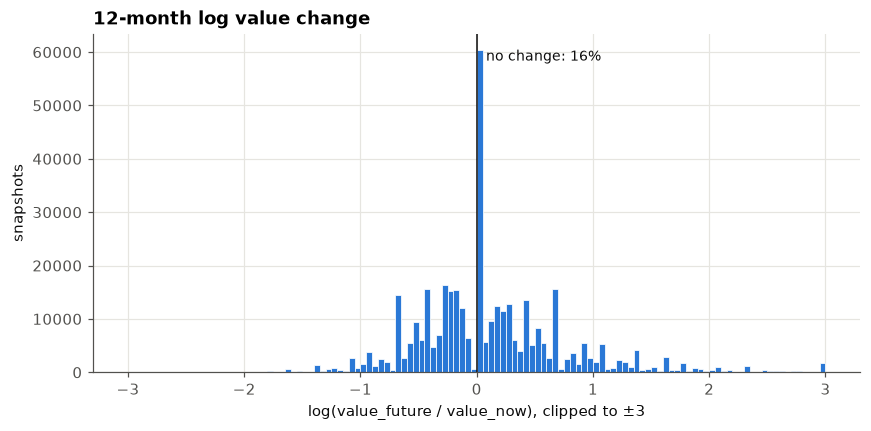

In [3]:
fig, ax = plt.subplots()
ax.hist(t.target.clip(-3, 3), bins=np.linspace(-3, 3, 121), color=BLUE, edgecolor="white", linewidth=0.5)
ax.axvline(0, color=INK, linewidth=1)
ax.set(title="12-month log value change", xlabel="log(value_future / value_now), clipped to ±3", ylabel="snapshots")
ax.text(0.08, 0.92, f"no change: {share['no change']:.0%}", color=INK, fontsize=9, transform=ax.get_xaxis_transform())
plt.show()

The spike at exactly 0 (unchanged value) matters for Phase 2: it makes the "no change" baseline strong on MAE, and directional accuracy needs an explicit rule for zero (e.g., count it as its own class, or exclude it).

## 2. Coverage by league and season

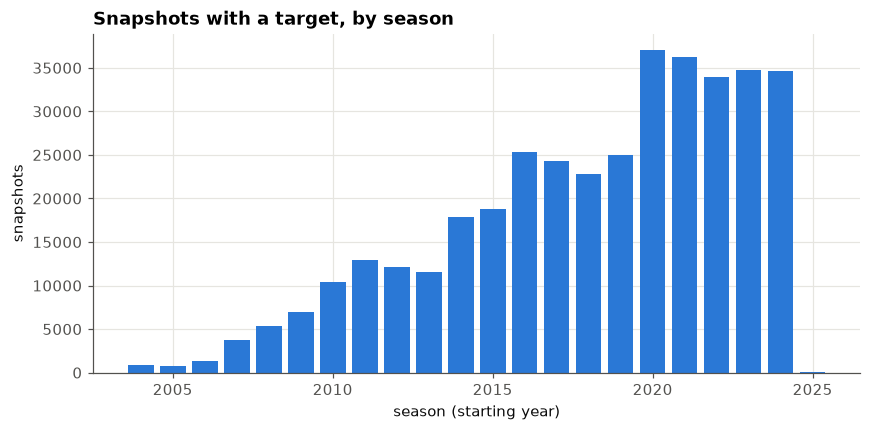

season,2018,2019,2020,2021,2022,2023,2024,2025
snapshots,22796,24967,37053,36242,33930,34808,34681,49


In [4]:
per_season = t.groupby("season").size()
fig, ax = plt.subplots()
ax.bar(per_season.index, per_season.values, color=BLUE, width=0.8)
ax.set(title="Snapshots with a target, by season", xlabel="season (starting year)", ylabel="snapshots")
plt.show()
per_season.tail(8).to_frame("snapshots").T

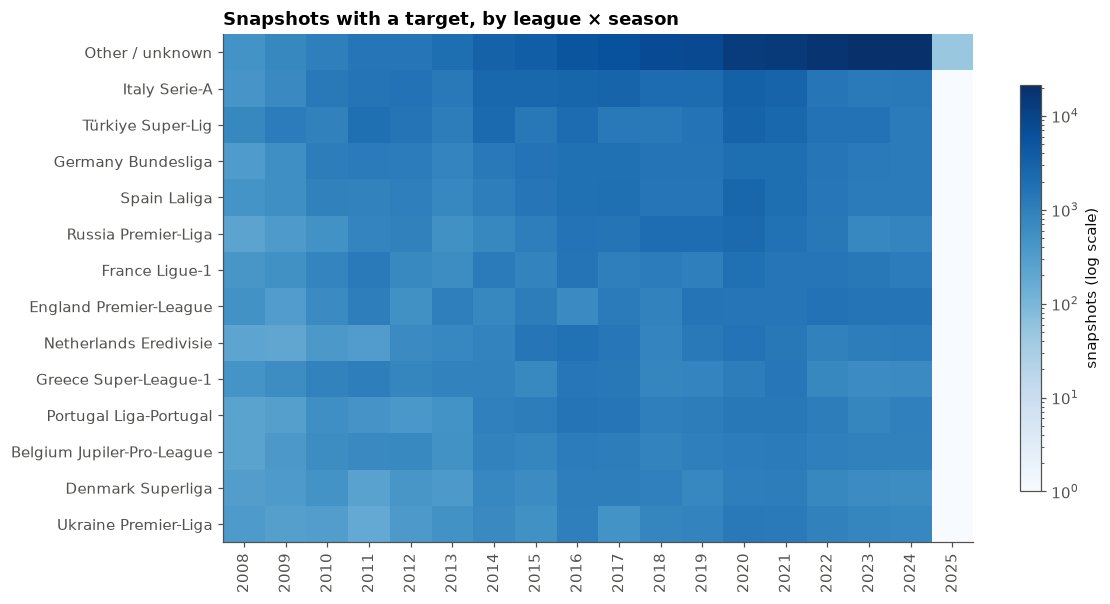

season,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
player_club_domestic_competition_id,,,,,,,,,,,,,,,,,,
Other / unknown,482,732,987,1504,1406,1942,3083,3688,5213,6008,7258,7910,13286,14748,18170,21082,21360,48
Italy Serie-A,431,689,1276,1557,1662,1256,2512,2513,2775,2835,2088,2144,3185,2927,1444,1221,1268,0
Türkiye Super-Lig,736,1139,935,1846,1531,1083,2271,1325,2101,1261,1253,1602,2939,2574,1691,1651,1177,0
Germany Bundesliga,334,552,1094,1161,1142,832,1256,1626,1813,1826,1561,1544,1929,1939,1443,1220,1182,0
Spain Laliga,456,560,942,891,987,770,1056,1455,1784,1880,1404,1412,2672,1982,1362,1157,1182,0
Russia Premier-Liga,230,348,493,814,919,521,738,1038,1633,1533,2016,1999,2289,1730,1312,769,842,0
France Ligue-1,408,510,822,1221,694,610,1165,845,1547,1021,1113,1000,1818,1456,1419,1307,1110,1
England Premier-League,491,315,661,1048,509,1020,730,1094,662,1186,882,1560,1492,1399,1671,1523,1516,0
Netherlands Eredivisie,223,201,378,311,665,760,849,1413,1757,1378,830,1272,1589,1319,924,1068,1115,0


In [5]:
names = comps.set_index("competition_id").apply(lambda r: f"{r.country_name or ''} {r['name']}".strip().title(), axis=1)
league = t.player_club_domestic_competition_id.map(names).fillna("Other / unknown")
top = league.value_counts().index[:14]
cov = (pd.crosstab(league.where(league.isin(top), "Other / unknown"), t.season)
         .loc[:, 2008:].reindex(list(top) + (["Other / unknown"] if "Other / unknown" not in top else [])))
fig, ax = plt.subplots(figsize=(11, 6))
from matplotlib.colors import LogNorm
im = ax.imshow(cov.values.clip(1), cmap="Blues", aspect="auto", norm=LogNorm())
ax.set_xticks(range(cov.shape[1]), cov.columns, rotation=90); ax.set_yticks(range(cov.shape[0]), cov.index)
ax.grid(False); ax.set_title("Snapshots with a target, by league × season")
fig.colorbar(im, ax=ax, label="snapshots (log scale)", shrink=0.8)
plt.show()
cov

## 3. Value curves by age

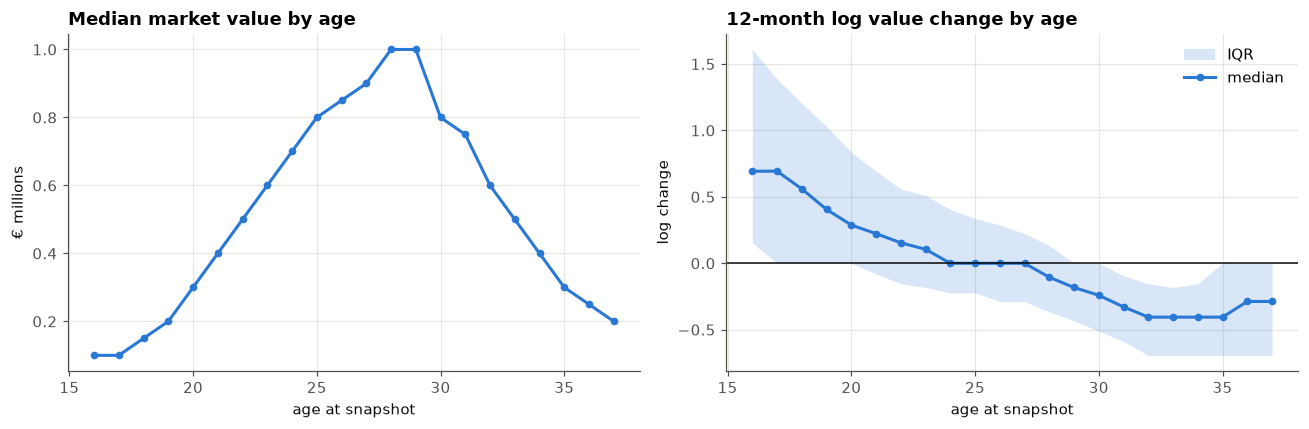

,median_value,n,q25,median_target,q75,mean_target
age_bin,,,,,,
16,100000.0,1231,0.154,0.693,1.609,0.975
17,100000.0,5276,0.000,0.693,1.386,0.887
18,150000.0,13893,0.000,0.560,1.204,0.725
19,200000.0,23321,0.000,0.405,1.030,0.575
20,300000.0,28997,0.000,0.288,0.836,0.450
21,400000.0,31375,-0.080,0.223,0.693,0.343
22,500000.0,32298,-0.154,0.154,0.560,0.253
23,600000.0,32191,-0.182,0.105,0.511,0.186
24,700000.0,31120,-0.223,0.000,0.405,0.132


In [6]:
a = t[t.age.between(16, 38)].assign(age_bin=lambda d: d.age.astype(int))
by_age = a.groupby("age_bin").agg(median_value=("value_now", "median"), n=("target", "size"),
                                  q25=("target", lambda s: s.quantile(.25)), median_target=("target", "median"),
                                  q75=("target", lambda s: s.quantile(.75)), mean_target=("target", "mean"))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(by_age.index, by_age.median_value / 1e6, color=BLUE, linewidth=2, marker="o", markersize=4)
ax1.set(title="Median market value by age", xlabel="age at snapshot", ylabel="€ millions")
ax2.fill_between(by_age.index, by_age.q25, by_age.q75, color=BLUE, alpha=0.18, linewidth=0, label="IQR")
ax2.plot(by_age.index, by_age.median_target, color=BLUE, linewidth=2, marker="o", markersize=4, label="median")
ax2.axhline(0, color=INK, linewidth=1)
ax2.set(title="12-month log value change by age", xlabel="age at snapshot", ylabel="log change")
ax2.legend(frameon=False)
plt.tight_layout(); plt.show()
by_age.round(3)

In [7]:
pos = a.groupby(["position", "age_bin"]).target.median().unstack(0)
pos.loc[[18, 21, 24, 27, 30, 33]].round(3)

position,Attack,Defender,Goalkeeper,Midfield,Missing
age_bin,,,,,
18,0.693,0.619,0.288,0.624,0.000
21,0.208,0.262,0.118,0.223,0.357
24,0.000,0.065,0.000,0.000,0.000
27,-0.065,0.000,0.000,0.000,0.000
30,-0.288,-0.223,-0.105,-0.288,-0.405
33,-0.405,-0.405,-0.288,-0.405,-0.549


## Findings (data snapshot to 2026-06-12)

- **Coverage:** 376,874 snapshots have a target (63% of those old enough). Season 2025 has only 49 because the data ends in June 2026, so the **test set is effectively the 2024 season**.
- **Target shape:** median 0 and mean +0.12. 16% of snapshots are exactly unchanged, 44% rise and 40% fall. Rises dominate the tails (99th percentile +2.37 vs 1st percentile -1.25), partly because the few players whose value collapses tend to drop out of coverage (survivorship bias).
- **Age is the dominant structure:** median change is about +0.7 at 16-17, crosses 0 around 24-27 and bottoms at about -0.4 from 32 to 35. Median value peaks at 28-29. Goalkeepers follow a flatter curve. Any model must beat an age-only curve, not just "no change".
- **League:** growth after 2019 comes mostly from clubs outside the 14 covered leagues ("Other / unknown", no competition id). Because the league label is the club's *current* league, Phase 2 derives league point-in-time from `games`.